### 1. Визуализация временных рядов для разных классов активности. 

In [2]:
from pathlib import Path

import pandas as pd

train_path = Path("../data/raw/train.csv")

train_df = pd.read_csv(train_path)

print(train_df.shape)
train_df.head()

(860752, 5)


,acc_x,acc_y,acc_z,timestamp,Activity
0,-5.09,8.50,-1.266692,1887.012279,0
1,-5.18,8.35,-1.375655,1887.062297,0
2,-5.20,9.34,-1.334794,1887.112285,0
3,-4.25,9.11,-1.266692,1887.162273,0
4,-3.30,8.96,-1.307553,1887.212260,0


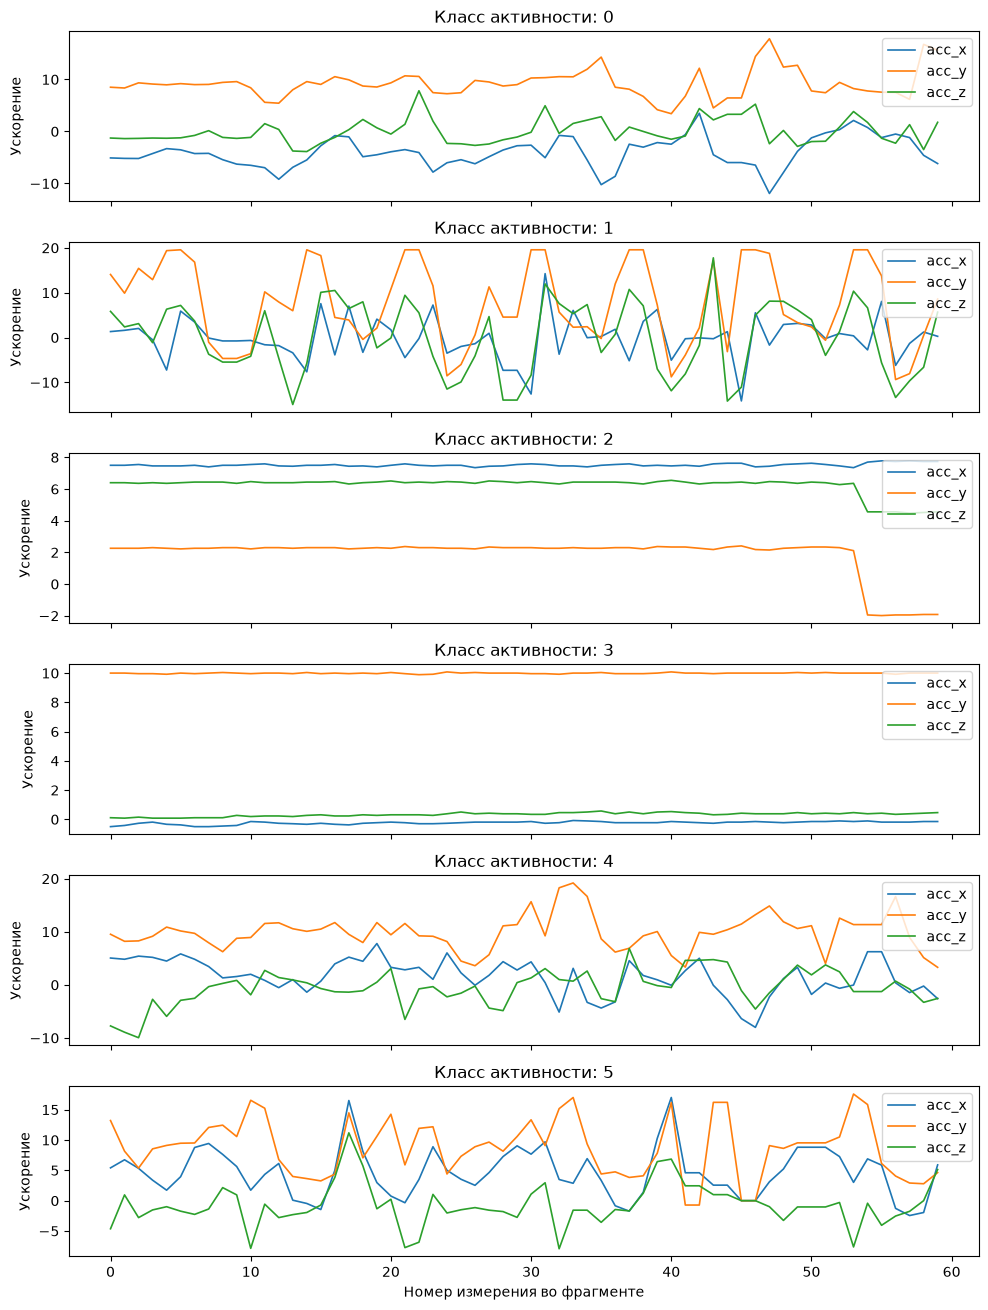

In [4]:
import matplotlib.pyplot as plt

axis_columns = ["acc_x", "acc_y", "acc_z"]
classes = sorted(train_df["Activity"].unique())

points_per_class = 60

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=1,
    figsize=(10, 2.2 * len(classes)),
    sharex=True
)

for ax, activity_class in zip(axes, classes):
    sample = train_df[train_df["Activity"] == activity_class].head(points_per_class).copy()
    sample["point_number"] = range(len(sample))

    for column in axis_columns:
        ax.plot(
            sample["point_number"],
            sample[column],
            label=column,
            linewidth=1.2
        )

    ax.set_title(f"Класс активности: {activity_class}")
    ax.set_ylabel("Ускорение")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Номер измерения во фрагменте")

plt.tight_layout()
plt.show()

Для каждого класса активности построен небольшой фрагмент временного ряда по трем осям акселерометра.
Мспользуется номер измерения внутри выбранного фрагмента, а не абсолютное время. Сравнение классов стало более наглядным и отсутствуют искажения.

 ### 2. Анализ баланса классов (построение bar-plot распределения активностей). 

In [5]:
class_counts = train_df["Activity"].value_counts().sort_index()

class_counts

Activity
0     79642
1    273579
2     49853
3     40217
4     92754
5    324707
Name: count, dtype: int64

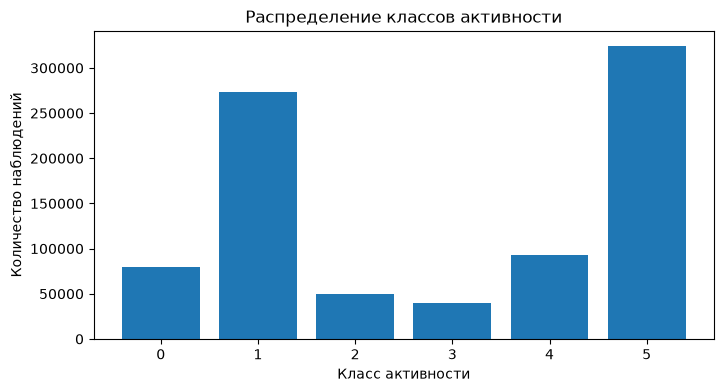

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(class_counts.index.astype(str), class_counts.values)

plt.title("Распределение классов активности")
plt.xlabel("Класс активности")
plt.ylabel("Количество наблюдений")

plt.show()

По графику видно, что классы активности распределены неравномерно.
В датасете присутствует дисбаланс классов, так как значения классов 1 и 5 значительно превышают остальные.